In [1]:
%load_ext autoreload
%autoreload 2

# Document Parsing

In [2]:
from kb_mcp.parser import parse
import json

In [3]:
# find a good file to parse
file_path = "/Users/scorrodi/Desktop/inspire-510785_10.pdf"

## kb-mcp default parsing

In [4]:
results = parse(file_path)

In [5]:
print(f"Number of results: {len(results)}")

Number of results: 1


In [6]:
result = results[0]
result.keys()

dict_keys(['source_id', 'doc_id', 'source_type', 'meta', 'uri', 'text', 'doc_type'])

In [7]:
{k: v for k, v in result.items() if k in ['source_id', 'doc_id', 'source_type', 'uri', 'doc_type']}

{'source_id': 'local',
 'doc_id': 'inspire-510785_10',
 'source_type': 'application/pdf',
 'uri': 'file:///Users/scorrodi/Desktop/inspire-510785_10.pdf',
 'doc_type': 'text'}

In [8]:
print(result.get('text'))

SLAC-PUB-8311
Electroweak Precision Measurement with Leptons
Work supported by Department of Energy contract DE–AC03–76SF00515.December 1999
Invited talk presented at International Europhysics Conference on High-Energy
Physics, 7/15/1999—7/15/1999, Tampere, FinlandJames E. Brau, for the SLD Collaboration
Physics Department, University of Oregon, Eugene, OR 97403-1274 USA
E-mail: jimbrau@faraday.uoregon.edu
Stanford Linear Accelerator Center, Stanford University, Stanford, CA 94309

hep-ex/9911040   26 Nov 1999
Electro w eak Precision Measuremen tswith LeptonsJames E/. Brau/, for the SLD Collab orationPh ysics Departmen t/, Univ ersit y of Oregon/, Eugene/, OR /9/7/4/0/3/-/1/2/7/4 USAE/-mail/: jimbrau/@fa rad ay /.uo reg on /.ed uAbstractThe precision measuremen ts of lepton electro w eak parameters at SLD and LEPare review ed and discussed/. The up dated SLD w eak mixing angle measuremen tfrom ALR
and the lepton left/-righ t forw ard/-bac kw ard asymmetries is sin
/2/#12
ef fW
/=/0 /: 

### Extract images

In [9]:
results = parse(file_path, extract_images=True)

In [10]:
print(f"Number of results: {len(results)}")

Number of results: 2


In [13]:
for result in results:
    print(json.dumps(
    {k: v for k, v in result.items() if k in ['source_id', 'doc_id', 'source_type', 'uri', 'doc_type']},
    indent=2
))

{
  "source_id": "local",
  "doc_id": "inspire-510785_10",
  "source_type": "application/pdf",
  "uri": "file:///Users/scorrodi/Desktop/inspire-510785_10.pdf",
  "doc_type": "text"
}
{
  "doc_id": "inspire-510785_10-image-1.png",
  "source_id": "local",
  "source_type": "image/png",
  "doc_type": "image"
}


In [14]:
img = results[1]

In [15]:
img['meta']

{'page': 4,
 'image_number': 1,
 'image_name': 'image-1.png',
 'parent_doc_id': 'inspire-510785_10',
 'filename': 'inspire-510785_10.pdf',
 'filepath': '/Users/scorrodi/Desktop/inspire-510785_10.pdf',
 'filesize': 142814}

In [16]:
from kb_mcp.parser import display_image

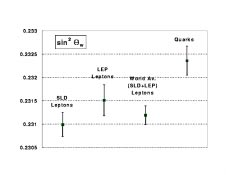

In [17]:
display_image(img)

In [18]:
print(results[0].get("text"))

SLAC-PUB-8311
Electroweak Precision Measurement with Leptons
Work supported by Department of Energy contract DE–AC03–76SF00515.December 1999
Invited talk presented at International Europhysics Conference on High-Energy
Physics, 7/15/1999—7/15/1999, Tampere, FinlandJames E. Brau, for the SLD Collaboration
Physics Department, University of Oregon, Eugene, OR 97403-1274 USA
E-mail: jimbrau@faraday.uoregon.edu
Stanford Linear Accelerator Center, Stanford University, Stanford, CA 94309

hep-ex/9911040   26 Nov 1999
Electro w eak Precision Measuremen tswith LeptonsJames E/. Brau/, for the SLD Collab orationPh ysics Departmen t/, Univ ersit y of Oregon/, Eugene/, OR /9/7/4/0/3/-/1/2/7/4 USAE/-mail/: jimbrau/@fa rad ay /.uo reg on /.ed uAbstractThe precision measuremen ts of lepton electro w eak parameters at SLD and LEPare review ed and discussed/. The up dated SLD w eak mixing angle measuremen tfrom ALR
and the lepton left/-righ t forw ard/-bac kw ard asymmetries is sin
/2/#12
ef fW
/=/0 /: 

### Extract images and Descriptions

In [21]:
results = parse(file_path, extract_images=True, describe_images=True)

In [22]:
print(f"Number of results: {len(results)}")

Number of results: 2


In [23]:
img = results[1]

In [24]:
img.get('text')

'The graph displays the angular distribution of di-lepton events from $Z^0$ decays into $e^+e^-$, $\\mu^+\\mu^-$, and $\\tau^+\\tau^-$ at SLD. The x-axis represents $\\cos\\theta$, while the y-axis represents the number of events, with distributions shown for $Z^0 \\rightarrow e^+e^-$, $Z^0 \\rightarrow \\mu^+\\mu^-$, and $Z^0 \\rightarrow \\tau^+\\tau^-$. The plot shows distinct distributions for each decay mode, with varying numbers of events across the $\\cos\\theta$ range. The graph provides insight into the electroweak interactions and the properties of the $Z^0$ boson.'

In [33]:
print(results[0].get("text")[-700:])

s/.
Figure /2/. Comparison of the lepton/- and quark/-basedmeasuremen ts of the electro w eak mixing angle

![Image 1: The graph displays the angular distribution of di-lepton events from $Z^0$ decays into $e^+e^-$, $\mu^+\mu^-$, and $\tau^+\tau^-$ at SLD. The x-axis represents $\cos\theta$, while the y-axis represents the number of events, with distributions shown for $Z^0 \rightarrow e^+e^-$, $Z^0 \rightarrow \mu^+\mu^-$, and $Z^0 \rightarrow \tau^+\tau^-$. The plot shows distinct distributions for each decay mode, with varying numbers of events across the $\cos\theta$ range. The graph provides insight into the electroweak interactions and the properties of the $Z^0$ boson.](image-1.png)




### Use Marker


In [36]:
results = parse(file_path, 
                parser_name="marker",
                extract_images=True, 
                describe_images=True)


Recognizing Layout: 100%|██████████████████████████████████████████████████████████████████████| 4/4 [00:27<00:00,  6.86s/it]

Running OCR Error Detection: 100%|█████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.19s/it]

Detecting bboxes: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.01s/it]

Recognizing Text: 100%|████████████████████████████████████████████████████████████████████| 185/185 [03:00<00:00,  1.03it/s]

Detecting bboxes: 0it [00:00, ?it/s]


In [37]:
print(f"Number of results: {len(results)}")

Number of results: 2


In [38]:
for result in results:
    print(json.dumps(
    {k: v for k, v in result.items() if k in ['source_id', 'doc_id', 'source_type', 'uri', 'doc_type']},
    indent=2
))

{
  "source_id": "local",
  "doc_id": "inspire-510785_10",
  "source_type": "application/pdf",
  "uri": "file:///Users/scorrodi/Desktop/inspire-510785_10.pdf",
  "doc_type": "text"
}
{
  "source_id": "local",
  "doc_id": "inspire-510785_10-_page_3_Figure_3.jpeg",
  "doc_type": "image"
}


In [39]:
img = results[1]

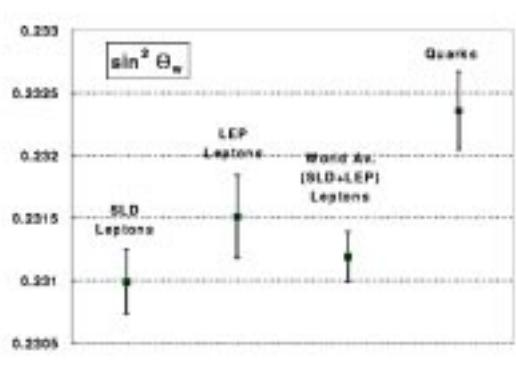

In [40]:
display_image(img)

In [41]:
img.get('text')

'The image is a technical plot comparing lepton- and quark-based measurements of the electroweak mixing angle. The plot displays data points and error bars for various measurements, with a clear distinction between lepton-based and quark-based results. The quark-based measurement is $0.23236 \\pm 0.00031$, while the lepton-based measurements from SLD and LEP are $0.23099\\pm0.00026$ and $0.23151 \\pm 0.00033$, respectively. The plot illustrates a significant difference between the quark sector and lepton-based results.'

In [42]:
print(results[0].get("text"))

**Electroweak Precision Measurement with Leptons**

James E. Brau, for the SLD Collaboration Physics Department, University of Oregon, Eugene, OR 97403-1274 USA E-mail: jimbrau@faraday.uoregon.edu

Work supported by Department of Energy contract DE–AC03–76SF00515.

*Stanford Linear Accelerator Center, Stanford University, Stanford, CA 94309*

Invited talk presented at International Europhysics Conference on High-Energy Physics, 7/15/1999—7/15/1999, Tampere, Finland

The 90's era of precision electroweak measurements at the Z has come to an end with the last run of SLD. SLD has completed the analysis of all of its data. The left-right asymmetry measurement, the SLD left-right forward-backward asymmetry for leptons, and the LEP tau polarization measurements have all recently been updated. Here we summarize these recent results.

2. SLD Left-right Asymmetry

1. Introduction

**Electroweak Precision Measurements** 

with Leptons

James E. Brau, for the SLD Collaboration

Physics Department